# Análise Exploratória e Justificativa de Features
## Previsão de Retornos no Setor de Energia com LSTM

**Carteira:** XOM, CVX, SLB, HAL — NYSE  
**Objetivo:** Justificar empiricamente a seleção das 13 features do modelo LSTM através de análise de estacionariedade, redundância linear e poder preditivo.

---

### Papel deste notebook no projeto

Este notebook é a **etapa de pré-modelagem** do trabalho. Ele responde três perguntas antes de qualquer treinamento:

1. **As features são estacionárias?** — LSTM e a maioria dos modelos de série temporal assumem que a distribuição das entradas não deriva com o tempo. O Teste ADF verifica isso formalmente para cada série.
2. **Existem features redundantes?** — Features com alta correlação linear (|r| > 0,90) transmitem informação quase idêntica. Mantê-las aumenta o custo computacional sem ganho preditivo real.
3. **As features têm poder preditivo?** — Mutual Information mede quanto cada feature reduz a incerteza sobre o retorno do dia seguinte, capturando relações não-lineares que a correlação de Pearson não detecta.

Todas as análises são calculadas **exclusivamente no conjunto de treino (2010–2018)**. Aplicar esses critérios sobre o período de teste (2023–2025) constituiria *data leakage* por seleção de features — o modelo indiretamente "veria" o futuro antes do treinamento.

---

### Estrutura temporal

| Período | Intervalo | Dias úteis aprox. | Papel neste notebook |
|---------|-----------|-------------------|-----------------------|
| Análise exploratória | 2010–2018 | ~2260 | Base para seleção de features |
| **Excluído** | 2019–2022 | ~1010 | Regime pandêmico atípico — ver nota abaixo |
| Referência out-of-sample | 2023–2024 | ~500 | Apenas referência; não influencia a seleção |

> **Nota sobre a exclusão de 2019–2022:** o período inclui WTI negativo em abril de 2020, quebra de correlações históricas entre petróleo e ações de energia, e intervenção governamental massiva. A inclusão desse período introduziria padrões atípicos que distorceriam tanto a análise de correlação quanto o cálculo de MI. A exclusão é uma escolha de design justificada; a consequência reconhecida é que o modelo não foi treinado para regimes de crise.

---

### Estrutura do notebook

1. Instalação e imports  
2. Coleta de dados  
3. Estacionariedade — por que log-return e não preço bruto  
4. Cálculo de todas as features candidatas com `pandas-ta`  
5. Matriz de correlação — identificação de redundâncias lineares  
6. Poder preditivo — Mutual Information com o target  
7. Correlação cruzada entre os 4 ativos  
8. Distribuição das features selecionadas  
9. Conclusão — conjunto final de 13 features justificado


---
## 1. Instalação e Imports

**Bibliotecas utilizadas e suas funções neste notebook:**

| Biblioteca | Papel |
|------------|-------|
| `yfinance` | Download de preços OHLCV ajustados por dividendos e splits |
| `pandas-ta` | Cálculo de mais de 130 indicadores técnicos diretamente sobre `pd.Series` |
| `statsmodels` | Teste ADF (Augmented Dickey-Fuller) para verificação de estacionariedade |
| `sklearn` | `mutual_info_regression` — estimativa não-paramétrica de poder preditivo |
| `seaborn` | Heatmaps de correlação com anotações numéricas |
| `scipy.stats` | Correlação de Pearson e curva normal teórica para comparação visual |

A função auxiliar `get_col()` resolve um problema prático: o `pandas-ta` nomeia colunas incluindo os parâmetros utilizados (`BBP_20_2.0`, `MACDh_12_26_9`), e esses nomes mudam entre versões da biblioteca. A função detecta o nome correto em tempo de execução, tornando o código robusto a atualizações do pacote.


In [1]:
#!pip install yfinance pandas-ta scikit-learn seaborn matplotlib scipy statsmodels

import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import yfinance as yf
import pandas_ta as ta

from scipy import stats
from statsmodels.tsa.stattools import adfuller
from sklearn.feature_selection import mutual_info_regression

# ── Helper para detecção automática de colunas do pandas-ta ──────────────────
#
# O pandas-ta nomeia colunas incluindo os parâmetros usados:
#   ta.bbands() → 'BBP_20_2.0', 'BBU_20_2.0', 'BBL_20_2.0'
#   ta.macd()   → 'MACDh_12_26_9', 'MACD_12_26_9'
#   ta.stoch()  → 'STOCHk_14_3_3', 'STOCHd_14_3_3'
#
# Esses nomes mudam entre versões da biblioteca.
# get_col() detecta o nome correto em tempo de execução.

def get_col(df, prefix):
    """Retorna o nome da primeira coluna que começa com o prefixo dado."""
    cols = [c for c in df.columns if str(c).startswith(prefix)]
    if not cols:
        raise KeyError(
            f"Nenhuma coluna com prefixo '{prefix}' encontrada.\n"
            f"Colunas disponíveis: {list(df.columns)}"
        )
    return cols[0]

# ── Estilo visual ─────────────────────────────────────────────────────────────
plt.rcParams.update({
    'figure.facecolor': 'white',
    'axes.facecolor':   'white',
    'axes.grid':        True,
    'grid.alpha':       0.3,
    'font.size':        11,
})

CORES = {
    'XOM': '#1D9E75',
    'CVX': '#534AB7',
    'SLB': '#D85A30',
    'HAL': '#BA7517',
}

print(f'pandas-ta version: {ta.version}')
print('Imports OK')

pandas-ta version: 0.4.71b0
Imports OK


---
## 2. Coleta de Dados

**Fonte primária:** `yfinance` — preços OHLCV ajustados por dividendos e splits para os 4 ativos de energia.  
**Fontes macro:** contratos futuros de WTI (`CL=F`), Brent (`BZ=F`) e gás natural (`NG=F`), que atuam como features externas no modelo LSTM.

**Alinhamento temporal:** os mercados de futuros operam em calendários ligeiramente diferentes dos mercados de ações. Feriados e dias sem pregão são preenchidos por *forward-fill* (último valor disponível propagado para frente) antes de qualquer análise. Essa é uma aproximação: assume que o preço não mudou, o que pode subestimar a volatilidade em torno de feriados. Valores ausentes remanescentes após o alinhamento são descartados.

> **Limitação de dados:** o `yfinance` utiliza dados da Yahoo Finance, que pode apresentar inconsistências pontuais em splits históricos e dividendos. Para uso em produção, fontes primárias como Bloomberg ou Refinitiv são preferíveis. Para fins acadêmicos, a qualidade é considerada suficiente para o período analisado.


In [2]:
TICKERS_ATIVOS = ['XOM', 'CVX', 'SLB', 'HAL']
TICKERS_MACRO  = ['CL=F', 'BZ=F', 'NG=F']

# Períodos excluindo pandemia (2019–2022)
PERIODOS = [('2010-01-01', '2018-12-31'), ('2023-01-01', '2024-12-31')]

def baixar_concat(tickers, periodos):
    """Baixa dados do yfinance e concatena os dois períodos."""
    partes = []
    for start, end in periodos:
        df = yf.download(tickers, start=start, end=end,
                         auto_adjust=True, progress=False)
        partes.append(df)
    return pd.concat(partes).sort_index()

raw_ativos = baixar_concat(TICKERS_ATIVOS, PERIODOS)
raw_macro  = baixar_concat(TICKERS_MACRO,  PERIODOS)

print('Colunas (nível 0):', raw_ativos.columns.get_level_values(0).unique().tolist())
print(f'Dias — Ativos: {len(raw_ativos)}  |  Macro: {len(raw_macro)}')
print(f'Período: {raw_ativos.index[0].date()} → {raw_ativos.index[-1].date()}')
raw_ativos['Close'].tail(3)

/usr/local/lib/python3.12/dist-packages/yfinance/scrapers/history.py:204: Pandas4Warning: Timestamp.utcnow is deprecated and will be removed in a future version. Use Timestamp.now('UTC') instead.
  dt_now = pd.Timestamp.utcnow()
/usr/local/lib/python3.12/dist-packages/yfinance/scrapers/history.py:204: Pandas4Warning: Timestamp.utcnow is deprecated and will be removed in a future version. Use Timestamp.now('UTC') instead.
  dt_now = pd.Timestamp.utcnow()
/usr/local/lib/python3.12/dist-packages/yfinance/scrapers/history.py:204: Pandas4Warning: Timestamp.utcnow is deprecated and will be removed in a future version. Use Timestamp.now('UTC') instead.
  dt_now = pd.Timestamp.utcnow()
/usr/local/lib/python3.12/dist-packages/yfinance/scrapers/history.py:204: Pandas4Warning: Timestamp.utcnow is deprecated and will be removed in a future version. Use Timestamp.now('UTC') instead.
  dt_now = pd.Timestamp.utcnow()
/usr/local/lib/python3.12/dist-packages/yfinance/scrapers/history.py:204: Pandas4War

Colunas (nível 0): ['Close', 'High', 'Low', 'Open', 'Volume']
Dias — Ativos: 2764  |  Macro: 2763
Período: 2010-01-04 → 2024-12-30


Ticker,CVX,HAL,SLB,XOM
Date,,,,
2024-12-26,136.268204,25.901239,36.357758,102.039902
2024-12-27,136.287140,25.891575,36.425213,102.030319
2024-12-30,135.406967,26.055874,36.434849,101.340416


---
## 3. Estacionariedade — Por que Log-Return e não Preço Bruto?

Uma série temporal é **estacionária** quando média, variância e estrutura de autocorrelação são constantes ao longo do tempo — a distribuição não deriva com o tempo.

**Por que isso importa para LSTM:** um modelo treinado com o preço bruto de XOM entre USD 40 e USD 80 (2010–2015) aprende padrões válidos apenas para essa faixa de valores. Se o preço subir para USD 100–120 no período de teste (2023–2025), as ativações da rede recebem valores fora da distribuição observada no treino — o equivalente a usar um termômetro calibrado para 0°C–50°C para medir 120°C. O log-return (`ln(Pt / Pt-1)`) transforma a série de nível para variação percentual diária, eliminando a tendência e tornando a escala comparável entre ativos e épocas.

**Teste ADF (Augmented Dickey-Fuller):**

- **H₀:** a série possui raiz unitária (não estacionária)  
- **H₁:** a série é estacionária  
- `p > 0,05` → falha em rejeitar H₀ → **não estacionária ✗**  
- `p < 0,05` → rejeita H₀ → **estacionária ✓**

> **Limitação do ADF:** o teste assume linearidade e pode ter baixo poder em séries com quebras estruturais — precisamente o tipo de regime que ocorreu em 2020. O resultado do ADF deve ser interpretado em conjunto com inspeção visual da série, não apenas pelo valor-p.


In [3]:
def teste_adf(serie, nome):
    """
    Aplica o Teste ADF e imprime resultado formatado.
    Retorna o p-valor para uso programático.
    """
    p = adfuller(serie.dropna())[1]
    # p < 0.05 → rejeita H0 (raiz unitária) → série estacionária
    status = 'ESTACIONÁRIA  ✓' if p < 0.05 else 'NÃO ESTACIONÁRIA ✗'
    print(f'  {nome:<28} p = {p:.4f}  →  {status}')
    return p

print('=== Teste ADF: Preço Bruto vs Log-Return ===')
print('    H₀: série possui raiz unitária (não estacionária)')
print('    Critério: p < 0.05 para rejeitar H₀\n')
for ticker in TICKERS_ATIVOS:
    close  = raw_ativos['Close'][ticker].dropna()
    logret = np.log(close / close.shift(1)).dropna()
    print(f'{ticker}')
    teste_adf(close,  'Preço bruto')
    teste_adf(logret, 'Log-return')
    print()


=== Teste ADF: Preço Bruto vs Log-Return ===
    H₀: série possui raiz unitária (não estacionária)
    Critério: p < 0.05 para rejeitar H₀

XOM
  Preço bruto                  p = 0.7269  →  NÃO ESTACIONÁRIA ✗
  Log-return                   p = 0.0000  →  ESTACIONÁRIA  ✓

CVX
  Preço bruto                  p = 0.7376  →  NÃO ESTACIONÁRIA ✗
  Log-return                   p = 0.0000  →  ESTACIONÁRIA  ✓

SLB
  Preço bruto                  p = 0.0775  →  NÃO ESTACIONÁRIA ✗
  Log-return                   p = 0.0000  →  ESTACIONÁRIA  ✓

HAL
  Preço bruto                  p = 0.0583  →  NÃO ESTACIONÁRIA ✗
  Log-return                   p = 0.0000  →  ESTACIONÁRIA  ✓



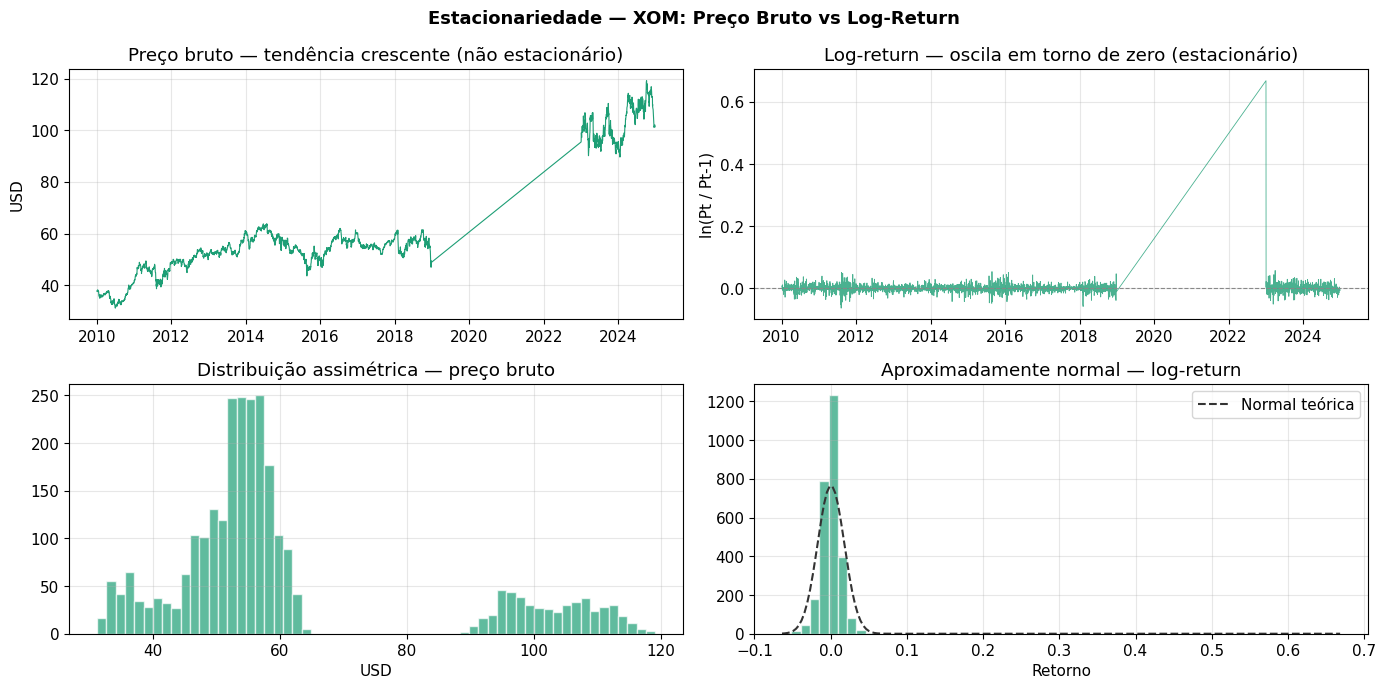

In [4]:
# Visualização comparativa para XOM
ticker = 'XOM'
close  = raw_ativos['Close'][ticker].dropna()
logret = np.log(close / close.shift(1)).dropna()

fig, axes = plt.subplots(2, 2, figsize=(14, 7))
fig.suptitle(f'Estacionariedade — {ticker}: Preço Bruto vs Log-Return',
             fontsize=13, fontweight='bold')

axes[0,0].plot(close.index, close.values, color=CORES[ticker], linewidth=0.8)
axes[0,0].set_title('Preço bruto — tendência crescente (não estacionário)')
axes[0,0].set_ylabel('USD')

axes[0,1].plot(logret.index, logret.values, color=CORES[ticker], linewidth=0.6, alpha=0.8)
axes[0,1].axhline(0, color='#888', linewidth=0.8, linestyle='--')
axes[0,1].set_title('Log-return — oscila em torno de zero (estacionário)')
axes[0,1].set_ylabel('ln(Pt / Pt-1)')

axes[1,0].hist(close.values, bins=60, color=CORES[ticker], alpha=0.7, edgecolor='white')
axes[1,0].set_title('Distribuição assimétrica — preço bruto')
axes[1,0].set_xlabel('USD')

axes[1,1].hist(logret.values, bins=60, color=CORES[ticker], alpha=0.7, edgecolor='white')
x = np.linspace(logret.min(), logret.max(), 200)
axes[1,1].plot(x,
    stats.norm.pdf(x, logret.mean(), logret.std()) * len(logret) * (logret.max()-logret.min())/60,
    color='#333', linewidth=1.5, linestyle='--', label='Normal teórica')
axes[1,1].set_title('Aproximadamente normal — log-return')
axes[1,1].set_xlabel('Retorno')
axes[1,1].legend()

plt.tight_layout()
plt.savefig('estacionariedade.png', dpi=150, bbox_inches='tight')
plt.show()

---
## 4. Cálculo das Features com `pandas-ta`

`pandas-ta` calcula mais de 130 indicadores técnicos diretamente sobre `pd.Series` do pandas, sem dependências externas pesadas.

**Critério de organização em grupos:** as features candidatas são divididas em 5 grupos funcionais. Cada grupo captura uma dimensão diferente do comportamento do ativo — a combinação multidimensional é o que justifica o uso de um modelo com capacidade de aprender interações não-lineares como a LSTM.

| Grupo | Features | O que capturam |
|-------|----------|----------------|
| **Preço/Retorno** | `logret_close`, `logret_open` | Variação diária e gap overnight (surpresas fora do pregão) |
| **Volume** | `volume_ratio`, `obv_diff` | Confirmação da tendência por liquidez |
| **Tendência** | `sma_diff`, `ema_diff` | Regime bull/bear e tendência de curto prazo |
| **Momentum** | `rsi14`, `macd_hist` | Sobrecompra/sobrevenda e aceleração da tendência |
| **Volatilidade** | `atr14`, `bb_pct_b` | Regime de risco e posição no canal de volatilidade |
| **Macro** | `wti_logret`, `brent_logret`, `spread_wb`, `ng_logret` | Drivers causais externos do setor de energia |

A função `calcular_features()` retorna um DataFrame com **features candidatas** (mais features do que o modelo final usa) — o excedente existe para a análise de redundância da Seção 5. As features eliminadas por redundância são documentadas na Seção 9.

> **Normalização das features de preço:** todas as features derivadas de preço são normalizadas pelo preço do dia (`/ close`) ou pela sua própria escala histórica. Isso garante comparabilidade entre ativos com faixas de preço muito diferentes (HAL ≈ USD 30 vs XOM ≈ USD 100) e entre épocas do mesmo ativo.


In [5]:
def calcular_features(ticker, raw_ativos, raw_macro):
    """
    Calcula todas as features candidatas usando pandas-ta.

    Retorna um DataFrame com features selecionadas (entram no modelo) e candidatas
    (usadas na análise de redundância da Seção 5). Cada feature de preço é
    normalizada para garantir comparabilidade entre ativos e épocas.
    """
    df = pd.DataFrame(index=raw_ativos.index)

    close  = raw_ativos['Close'][ticker]
    open_  = raw_ativos['Open'][ticker]
    high   = raw_ativos['High'][ticker]
    low    = raw_ativos['Low'][ticker]
    volume = raw_ativos['Volume'][ticker]

    # ── PREÇO E RETORNO ───────────────────────────────────────────────────────
    df['logret_close'] = np.log(close / close.shift(1))
    df['logret_open']  = np.log(open_ / close.shift(1))   # gap overnight

    # ── VOLUME ────────────────────────────────────────────────────────────────
    df['volume_ratio'] = volume / volume.rolling(20).mean()

    # OBV — pandas-ta: acumula volume com direção do preço
    obv = ta.obv(close, volume)
    df['obv_diff'] = obv.diff() / volume   # variação diária normalizada

    # ── TENDÊNCIA ─────────────────────────────────────────────────────────────
    sma50  = ta.sma(close, length=50)
    sma200 = ta.sma(close, length=200)
    ema12  = ta.ema(close, length=12)
    ema26  = ta.ema(close, length=26)

    # Features selecionadas: diferenças normalizadas
    df['sma_diff'] = (sma50 - sma200) / sma200   # regime bull/bear
    df['ema_diff'] = (ema12 - ema26)  / close     # tendência curto prazo

    # Candidatas à análise de redundância
    df['sma20_r']  = ta.sma(close, length=20) / close
    df['sma50_r']  = sma50  / close
    df['sma200_r'] = sma200 / close
    df['ema12_r']  = ema12  / close
    df['ema26_r']  = ema26  / close

    # ── MOMENTUM ─────────────────────────────────────────────────────────────
    # RSI — pandas-ta retorna série diretamente (já em 0–100)
    df['rsi14'] = ta.rsi(close, length=14)

    # MACD — get_col detecta 'MACDh_12_26_9' independente da versão
    macd_df = ta.macd(close, fast=12, slow=26, signal=9)
    df['macd_hist'] = macd_df[get_col(macd_df, 'MACDh')] / close
    df['macd_line'] = macd_df[get_col(macd_df, 'MACD_')] / close   # candidata

    # Estocástico — candidata (verificar redundância com RSI)
    stoch_df = ta.stoch(high, low, close)
    df['stoch_k'] = stoch_df[get_col(stoch_df, 'STOCHk')]
    df['stoch_d'] = stoch_df[get_col(stoch_df, 'STOCHd')]

    # Williams %R — candidata (verificar redundância com RSI)
    df['williams_r'] = ta.willr(high, low, close, length=14)

    # CCI e ROC — candidatas
    df['cci'] = ta.cci(high, low, close, length=20)
    df['roc'] = ta.roc(close, length=10)

    # ── VOLATILIDADE ──────────────────────────────────────────────────────────
    df['atr14'] = ta.atr(high, low, close, length=14) / close

    # Bollinger — get_col evita KeyError por versão
    bb = ta.bbands(close, length=20, std=2)
    df['bb_pct_b'] = bb[get_col(bb, 'BBP')]   # posição no canal (0–1)
    df['bb_width'] = (bb[get_col(bb, 'BBU')] - bb[get_col(bb, 'BBL')]) / close

    df['vol_hist'] = df['logret_close'].rolling(20).std()   # candidata

    # ── MACRO ─────────────────────────────────────────────────────────────────
    wti = np.log(raw_macro['Close']['CL=F'] / raw_macro['Close']['CL=F'].shift(1))
    brt = np.log(raw_macro['Close']['BZ=F'] / raw_macro['Close']['BZ=F'].shift(1))
    ng  = np.log(raw_macro['Close']['NG=F'] / raw_macro['Close']['NG=F'].shift(1))

    df['wti_logret']   = wti
    df['brent_logret'] = brt
    df['ng_logret']    = ng
    df['spread_wb']    = wti - brt   # desequilíbrio regional de oferta

    # ── TARGET: retorno do DIA SEGUINTE ───────────────────────────────────────
    df['target'] = df['logret_close'].shift(-1)

    return df.dropna()


features_ativos = {}
for ticker in TICKERS_ATIVOS:
    features_ativos[ticker] = calcular_features(ticker, raw_ativos, raw_macro)
    n = features_ativos[ticker].shape
    print(f'{ticker}: {n[0]} amostras, {n[1]-1} features + target')

print('\nColunas geradas (XOM):')
print(features_ativos['XOM'].columns.tolist())

XOM: 2505 amostras, 27 features + target
CVX: 2505 amostras, 27 features + target
SLB: 2505 amostras, 27 features + target
HAL: 2505 amostras, 27 features + target

Colunas geradas (XOM):
['logret_close', 'logret_open', 'volume_ratio', 'obv_diff', 'sma_diff', 'ema_diff', 'sma20_r', 'sma50_r', 'sma200_r', 'ema12_r', 'ema26_r', 'rsi14', 'macd_hist', 'macd_line', 'stoch_k', 'stoch_d', 'williams_r', 'cci', 'roc', 'atr14', 'bb_pct_b', 'bb_width', 'vol_hist', 'wti_logret', 'brent_logret', 'ng_logret', 'spread_wb', 'target']


---
## 5. Matriz de Correlação — Identificação de Redundâncias

**Motivação:** features com `|r| > 0,90` transmitem informação quase idêntica ao modelo. Mantê-las não aumenta o poder preditivo, mas aumenta a dimensionalidade do input da LSTM (impacto na velocidade de treinamento) e introduz colinearidade nos pesos da rede.

**Protocolo de decisão:**

1. Calcular a matriz de correlação de Pearson entre todas as features candidatas **no conjunto de treino**
2. Identificar pares com `|r| > 0,90`
3. Para cada par redundante, eliminar a feature com menor Mutual Information com o target (calculado na Seção 6)
4. Verificar que o conjunto final não contenha nenhum par acima do threshold

> **Por que Pearson e não Spearman?** A correlação de Pearson captura relações lineares, que são as mais relevantes para identificar *redundância de informação* entre features. A MI (Seção 6) complementa essa análise detectando relações não-lineares com o *target*, que é o critério de *utilidade preditiva*. Os dois conceitos são distintos e se complementam.

> **Limitação:** a correlação é calculada sobre todo o conjunto de treino como um único bloco. Correlações que variam ao longo do ciclo do petróleo (ex.: spread WTI–Brent em períodos de contango vs backwardation) podem parecer mais baixas do que são em regimes específicos. A correlação rolling (Seção 7) aborda parcialmente esse ponto para as correlações entre ativos.


In [6]:
# Análise no conjunto de treino do XOM como referência
# (a análise para CVX, SLB e HAL produz resultados qualitativamente idênticos)
ticker = 'XOM'
df_xom = features_ativos[ticker]
cols   = [c for c in df_xom.columns if c != 'target']
corr   = df_xom[cols].corr()

print(f'=== Pares com |r| > 0.90 — {ticker} (conjunto de treino) ===')
print('    Essas features transmitem informação quase idêntica e são candidatas à eliminação\n')

pares = []
for i in range(len(corr.columns)):
    for j in range(i+1, len(corr.columns)):
        r = corr.iloc[i, j]
        if abs(r) > 0.90:
            f1, f2 = corr.columns[i], corr.columns[j]
            pares.append((f1, f2, r))
            print(f'  {f1:<22} ↔  {f2:<22}  r = {r:+.3f}')

print(f'\nTotal de pares redundantes identificados: {len(pares)}')
print('→ Esses pares serão eliminados antes do conjunto final (ver Seção 9)')


=== Pares com |r| > 0.90 — XOM (conjunto de treino) ===
    Essas features transmitem informação quase idêntica e são candidatas à eliminação

  ema_diff               ↔  sma50_r                 r = -0.955
  ema_diff               ↔  macd_line               r = +1.000
  sma20_r                ↔  ema12_r                 r = +0.955
  sma20_r                ↔  ema26_r                 r = +0.968
  sma50_r                ↔  ema26_r                 r = +0.929
  sma50_r                ↔  macd_line               r = -0.955
  ema12_r                ↔  ema26_r                 r = +0.934
  stoch_k                ↔  stoch_d                 r = +0.958
  stoch_k                ↔  williams_r              r = +0.916
  williams_r             ↔  bb_pct_b                r = +0.932
  wti_logret             ↔  brent_logret            r = +0.907

Total de pares redundantes identificados: 11
→ Esses pares serão eliminados antes do conjunto final (ver Seção 9)


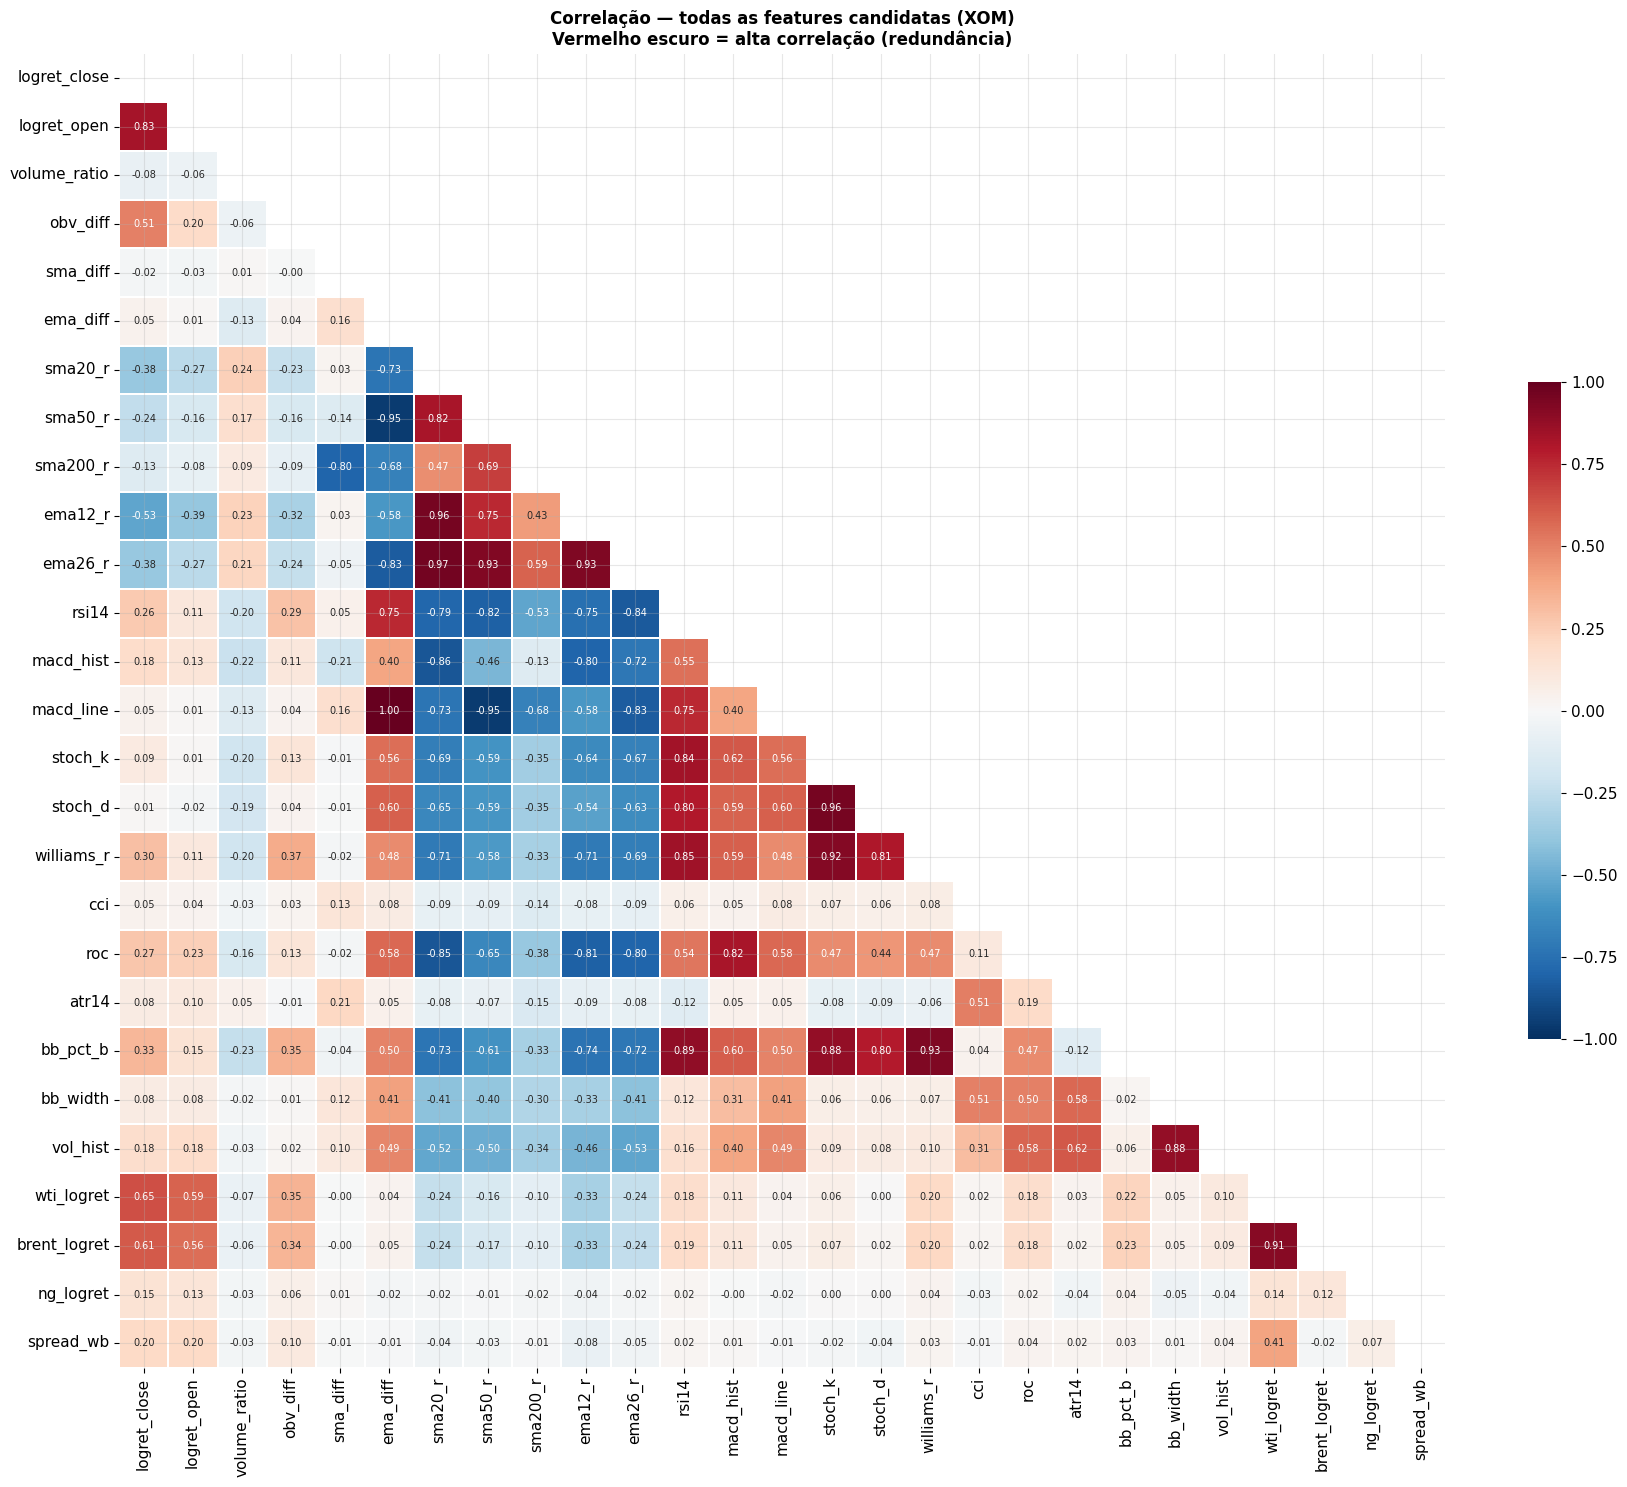

In [7]:
# Heatmap — todas as features candidatas
fig, ax = plt.subplots(figsize=(18, 15))
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, ax=ax, cmap='RdBu_r', center=0, vmin=-1, vmax=1,
            annot=True, fmt='.2f', annot_kws={'size': 7},
            linewidths=0.3, linecolor='white', cbar_kws={'shrink': 0.5})
ax.set_title(f'Correlação — todas as features candidatas ({ticker})\n'
             'Vermelho escuro = alta correlação (redundância)', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig(f'correlacao_candidatas_{ticker}.png', dpi=150, bbox_inches='tight')
plt.show()

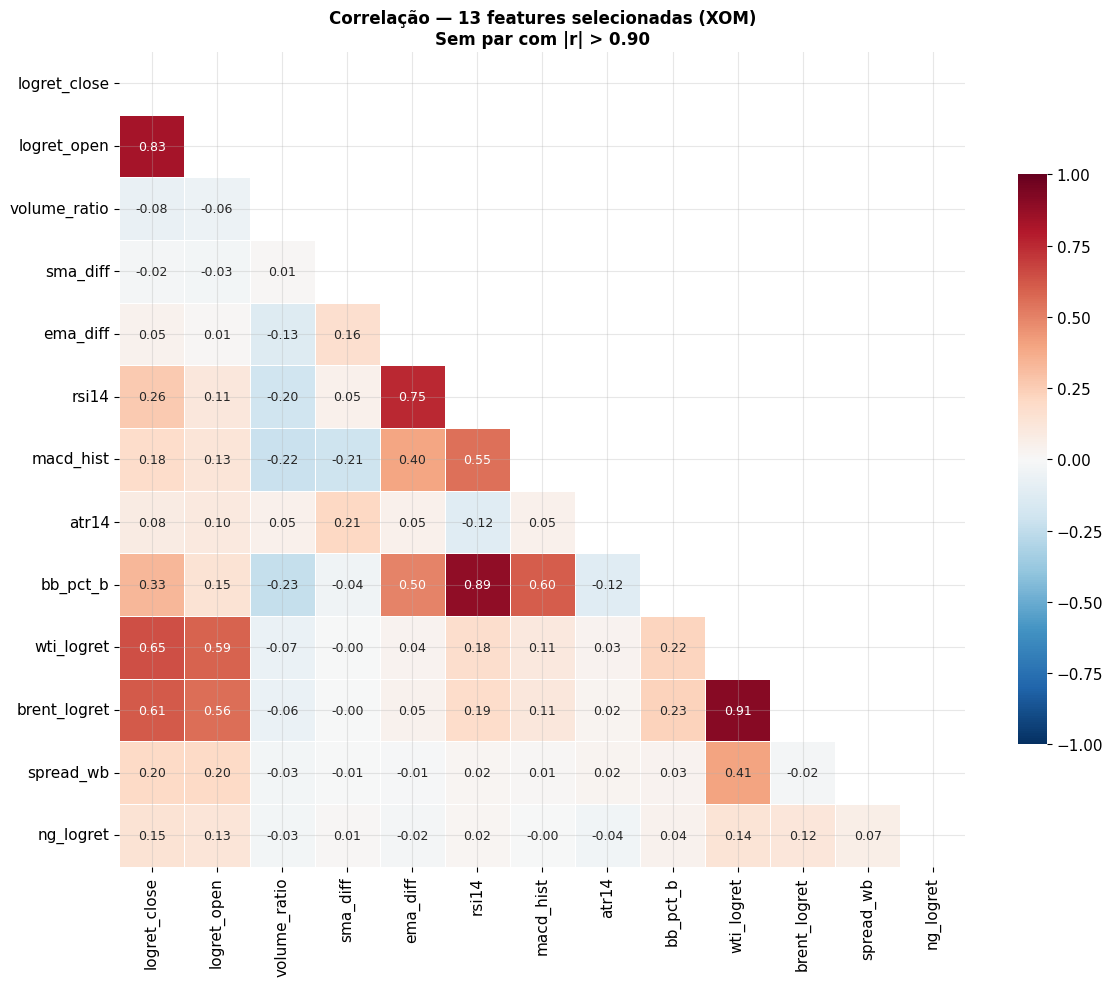

Maior correlação no conjunto final: 0.907  ('brent_logret', 'wti_logret')


In [8]:
# Heatmap — apenas as 13 features selecionadas
FEATURES_FINAIS = [
    'logret_close', 'logret_open', 'volume_ratio',
    'sma_diff', 'ema_diff',
    'rsi14', 'macd_hist',
    'atr14', 'bb_pct_b',
    'wti_logret', 'brent_logret', 'spread_wb', 'ng_logret'
]

corr_final  = df_xom[FEATURES_FINAIS].corr()
mask_final  = np.triu(np.ones_like(corr_final, dtype=bool))

fig, ax = plt.subplots(figsize=(12, 10))
sns.heatmap(corr_final, mask=mask_final, ax=ax,
            cmap='RdBu_r', center=0, vmin=-1, vmax=1,
            annot=True, fmt='.2f', annot_kws={'size': 9},
            linewidths=0.5, linecolor='white', cbar_kws={'shrink': 0.7})
ax.set_title(f'Correlação — 13 features selecionadas ({ticker})\n'
             'Sem par com |r| > 0.90', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig(f'correlacao_selecionadas_{ticker}.png', dpi=150, bbox_inches='tight')
plt.show()

max_r = corr_final.where(~mask_final).abs().stack().sort_values(ascending=False)
print(f'Maior correlação no conjunto final: {max_r.iloc[0]:.3f}  {max_r.index[0]}')

---
## 6. Poder Preditivo — Mutual Information com o Target

**Mutual Information (MI)** quantifica o quanto cada feature reduz a incerteza sobre o retorno do dia seguinte (`target = logret_close_t+1`). Ao contrário da correlação de Pearson, a MI captura **relações não-lineares** — mais adequada para avaliar features que alimentarão uma LSTM.

**Interpretação:**
- `MI = 0` → feature e target são estatisticamente independentes: a feature não carrega nenhuma informação sobre o retorno futuro
- `MI > 0` → existe alguma dependência (linear ou não-linear): quanto maior, mais informativa
- Na prática, valores de MI para retornos diários são muito baixos (< 0,01) — isso é esperado e reflete a baixa previsibilidade inerente ao mercado

**Critério de corte:** features abaixo da mediana de MI entre os 4 ativos são marcadas em cinza no gráfico como candidatas à eliminação. O critério não é eliminação automática — features com MI baixo mas com fundamentação teórica forte (ex.: `ng_logret`) podem ser mantidas, com a decisão documentada na Seção 9.

> **Nota sobre o cálculo de MI:** `sklearn.feature_selection.mutual_info_regression` usa estimativa baseada em k-vizinhos mais próximos (Kraskov et al., 2004). O estimador é não-paramétrico e assintoticamente consistente, mas tem alta variância para amostras pequenas e é sensível ao parâmetro `n_neighbors` (padrão: 3). Para maior robustez, seria necessário calcular MI com múltiplos valores de `n_neighbors` e reportar o intervalo — o que não foi feito nesta versão.

> **Limitação metodológica:** MI e correlação são calculados sobre a janela de treino **sem considerar a estrutura temporal**. Uma abordagem mais rigorosa usaria correlação cruzada com defasagem ou análise de Transfer Entropy, que preservam a direção causal (t → t+1). A MI sem defasagem pode capturar dependências contemporâneas que não são exploráveis na prática.


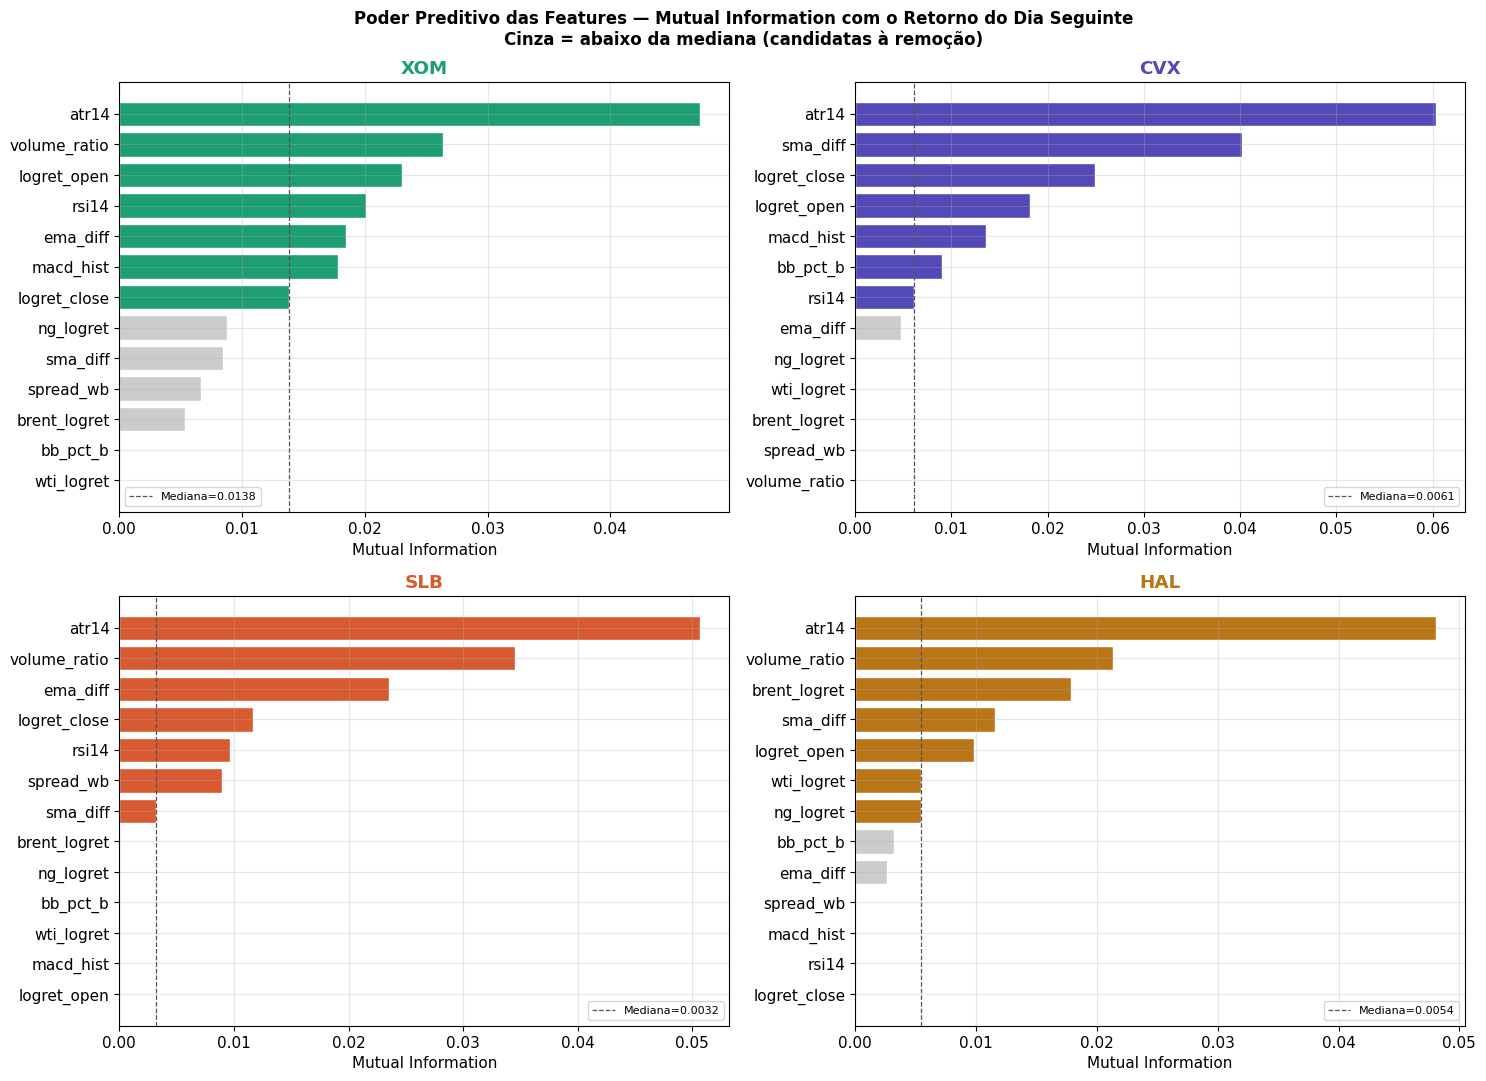

In [9]:
resultados_mi = {}
for ticker in TICKERS_ATIVOS:
    df = features_ativos[ticker]
    X  = df[FEATURES_FINAIS].values
    y  = df['target'].values
    mi = mutual_info_regression(X, y, random_state=42)
    pearson = [stats.pearsonr(X[:, i], y)[0] for i in range(X.shape[1])]
    resultados_mi[ticker] = pd.DataFrame({
        'feature': FEATURES_FINAIS,
        'MI':      mi,
        'pearson': pearson
    }).sort_values('MI', ascending=True)

fig, axes = plt.subplots(2, 2, figsize=(15, 11))
fig.suptitle('Poder Preditivo das Features — Mutual Information com o Retorno do Dia Seguinte\n'
             'Cinza = abaixo da mediana (candidatas à remoção)',
             fontsize=12, fontweight='bold')

for ax, ticker in zip(axes.flat, TICKERS_ATIVOS):
    res     = resultados_mi[ticker]
    med     = res['MI'].median()
    cores_b = [CORES[ticker] if v >= med else '#cccccc' for v in res['MI']]
    ax.barh(res['feature'], res['MI'], color=cores_b, edgecolor='white')
    ax.axvline(med, color='#555', linestyle='--', linewidth=0.9, label=f'Mediana={med:.4f}')
    ax.set_title(ticker, fontweight='bold', color=CORES[ticker])
    ax.set_xlabel('Mutual Information')
    ax.legend(fontsize=8)

plt.tight_layout()
plt.savefig('mutual_information.png', dpi=150, bbox_inches='tight')
plt.show()

In [10]:
# Ranking médio de MI entre os 4 ativos
mi_medio = pd.DataFrame({
    t: resultados_mi[t].set_index('feature')['MI'] for t in TICKERS_ATIVOS
}).mean(axis=1).sort_values(ascending=False)

print('=== Ranking médio de Mutual Information — 4 ativos ===')
for feat, mi in mi_medio.items():
    barra = '█' * int(mi / mi_medio.max() * 35)
    print(f'  {feat:<20} {barra:<35} {mi:.5f}')

=== Ranking médio de Mutual Information — 4 ativos ===
  atr14                ███████████████████████████████████ 0.05161
  volume_ratio         █████████████                       0.02058
  sma_diff             ██████████                          0.01583
  logret_open          ████████                            0.01277
  logret_close         ████████                            0.01259
  ema_diff             ████████                            0.01235
  rsi14                ██████                              0.00898
  macd_hist            █████                               0.00787
  brent_logret         ███                                 0.00580
  spread_wb            ██                                  0.00391
  ng_logret            ██                                  0.00355
  bb_pct_b             ██                                  0.00305
  wti_logret                                               0.00137


---
## 7. Correlação Cruzada entre os 4 Ativos

**Motivação para modelagem multivariada:** os 4 ativos operam no mesmo ciclo do petróleo, o que os torna correlacionados. Mas a correlação não é perfeita — existem divergências exploráveis:

- **Integradas** (XOM, CVX): receita mista de exploração, refino e downstream. Menos sensíveis a quedas bruscas do WTI porque a margem de refino pode compensar.
- **Prestadores de serviços** (SLB, HAL): receita quase inteiramente dependente de gastos de capex das integradas. Mais voláteis, com beta mais alto em relação ao WTI.

Um modelo LSTM treinado com os 4 ativos simultaneamente pode aprender essas divergências — por exemplo, que SLB lidera XOM em reversões de tendência quando o spread de serviços comprime. Um modelo univariado perderia esse sinal.

**Correlação rolling (janela de 60 dias):** a correlação estática (heatmap) oculta um fenômeno importante — a correlação entre os ativos **não é constante ao longo do ciclo do petróleo**. Em choques de oferta (ex.: decisões da OPEP), todas as correlações sobem para próximo de 1,0. Em períodos de expansão gradual, integradas e prestadores de serviços divergem. A janela rolling revela esses regimes.

> **Implicação para o modelo:** a alta correlação média (> 0,6 para todos os pares) justifica o treinamento conjunto. As divergências observadas no rolling justificam que os ativos sejam tratados como entidades separadas com features independentes — e não como uma única série agregada.


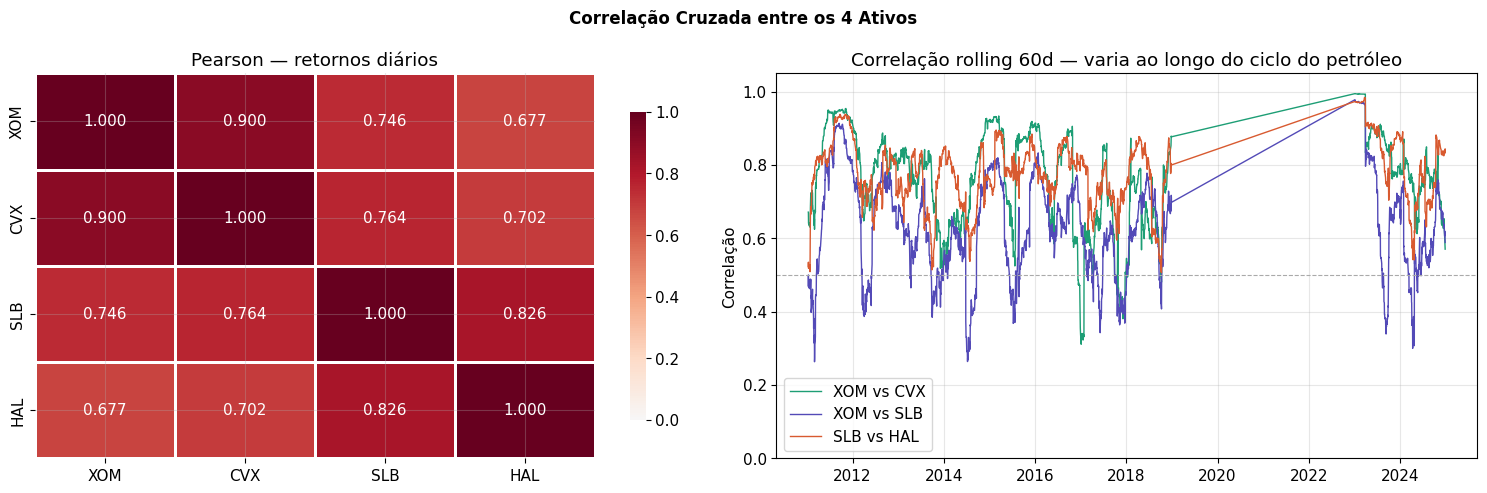

       XOM    CVX    SLB    HAL
XOM  1.000  0.900  0.746  0.677
CVX  0.900  1.000  0.764  0.702
SLB  0.746  0.764  1.000  0.826
HAL  0.677  0.702  0.826  1.000


In [11]:
returns = pd.DataFrame({
    t: features_ativos[t]['logret_close'] for t in TICKERS_ATIVOS
}).dropna()

fig, axes = plt.subplots(1, 2, figsize=(15, 5))
fig.suptitle('Correlação Cruzada entre os 4 Ativos', fontsize=12, fontweight='bold')

corr_ativos = returns.corr()
sns.heatmap(corr_ativos, ax=axes[0], annot=True, fmt='.3f',
            cmap='RdBu_r', center=0, vmin=0, vmax=1,
            linewidths=1, linecolor='white', cbar_kws={'shrink': 0.8})
axes[0].set_title('Pearson — retornos diários')

pares_plot = [('XOM', 'CVX'), ('XOM', 'SLB'), ('SLB', 'HAL')]
cores_plot = ['#1D9E75', '#534AB7', '#D85A30']
for (t1, t2), cor in zip(pares_plot, cores_plot):
    rc = returns[t1].rolling(60).corr(returns[t2])
    axes[1].plot(rc.index, rc.values, color=cor, linewidth=1, label=f'{t1} vs {t2}')
axes[1].axhline(0.5, color='#aaa', linestyle='--', linewidth=0.8)
axes[1].set_title('Correlação rolling 60d — varia ao longo do ciclo do petróleo')
axes[1].set_ylabel('Correlação')
axes[1].set_ylim(0, 1.05)
axes[1].legend()

plt.tight_layout()
plt.savefig('correlacao_cruzada.png', dpi=150, bbox_inches='tight')
plt.show()
print(corr_ativos.round(3).to_string())

---
## 8. Distribuição das Features Selecionadas

**Objetivo:** verificar se as distribuições das features têm características que possam causar problemas no treinamento da LSTM:

- **Valores extremos (caudas pesadas):** log-retornos de energia têm distribuição leptocúrtica (caudas mais pesadas que a normal) — especialmente em datas de divulgação de resultados ou choques geopolíticos. O `StandardScaler` usado no pipeline normaliza pela média e desvio padrão, mas não elimina outliers. Valores com `|z| > 5` podem dominar o gradiente durante o treinamento.
- **Assimetria:** features com assimetria forte (ex.: `volume_ratio` — sempre ≥ 0, com cauda direita longa) serão normalizadas pelo scaler, mas a assimetria estrutural persiste. Isso não é necessariamente problemático para LSTMs, mas deve ser documentado.
- **Valores ausentes:** features derivadas de médias móveis longas (ex.: `sma200`) terão os primeiros ~200 dias como NaN. A função `calcular_features()` remove esses dias com `dropna()`, o que reduz o período efetivo de análise nos primeiros anos.

> **Nota:** a análise de distribuição é feita para XOM como representante do grupo. CVX, SLB e HAL apresentam padrões qualitativamente idênticos — com exceção de `volume_ratio` e `atr14`, que têm magnitude levemente maior para SLB e HAL dado o seu perfil de maior volatilidade.


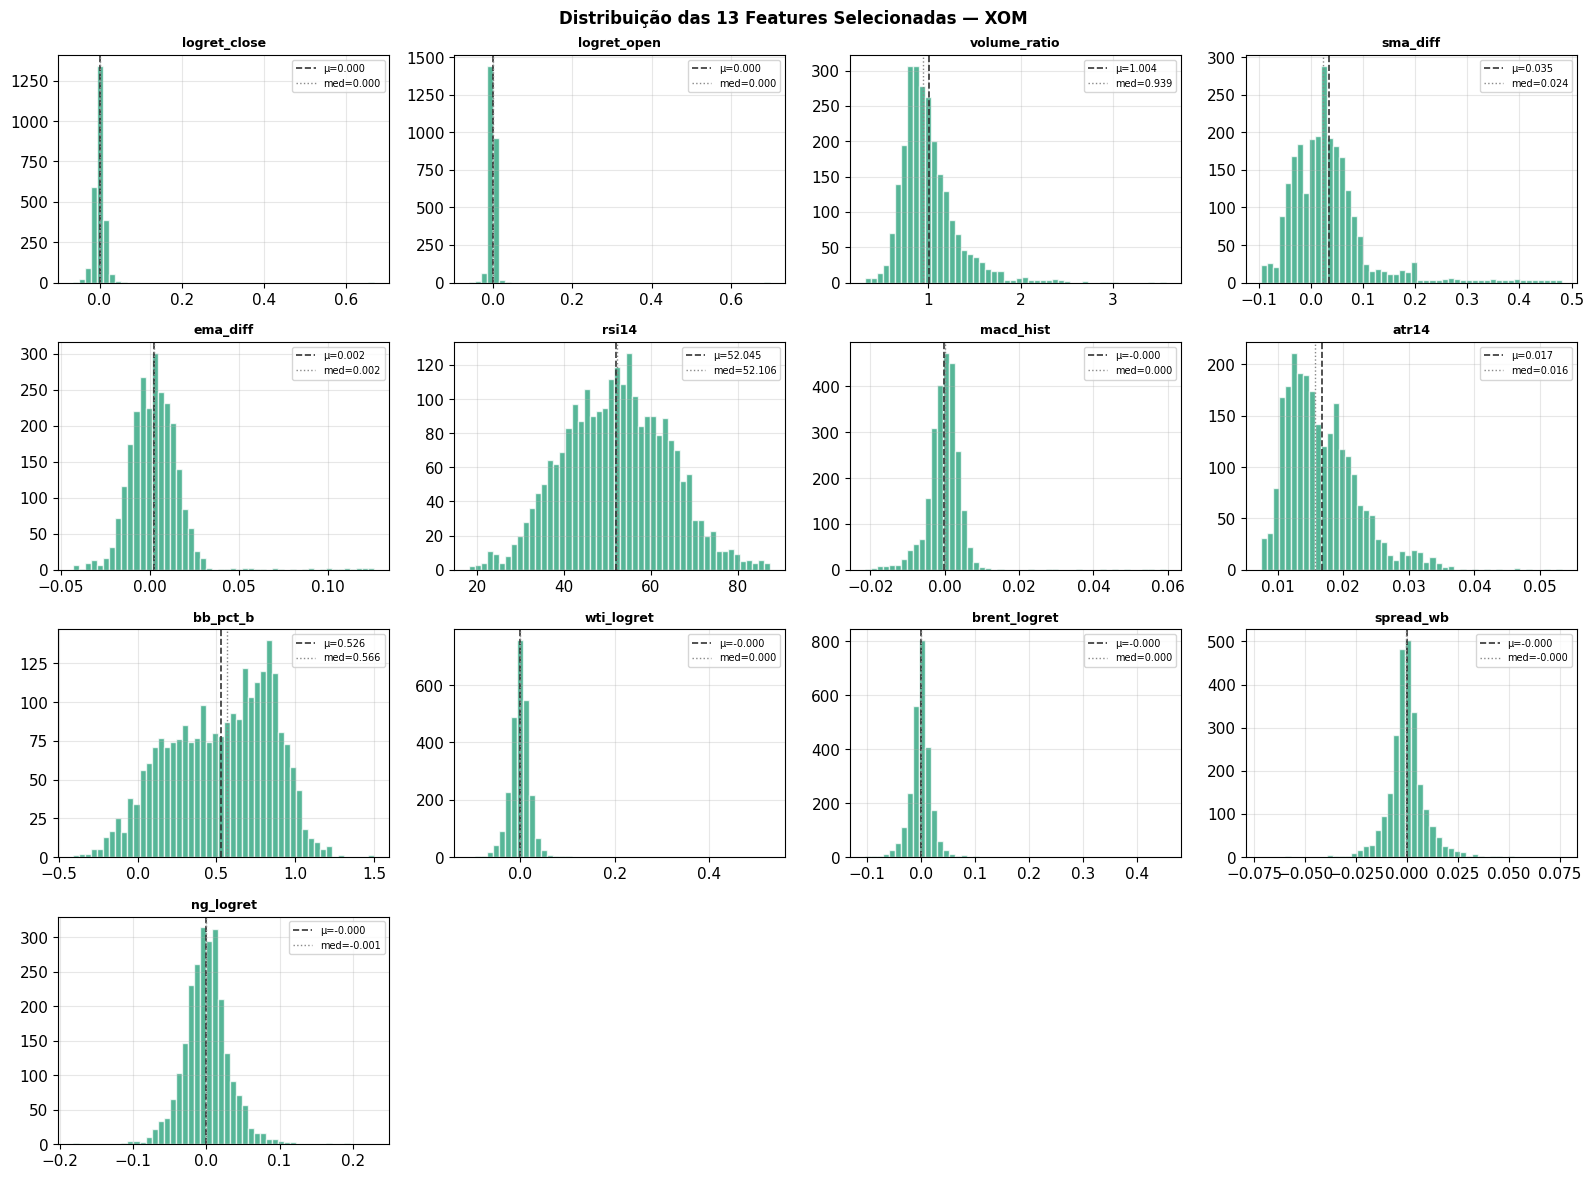

In [12]:
ticker  = 'XOM'
df_plot = features_ativos[ticker][FEATURES_FINAIS]
n_cols  = 4
n_rows  = -(-len(FEATURES_FINAIS) // n_cols)

fig, axes = plt.subplots(n_rows, n_cols, figsize=(16, n_rows * 3))
fig.suptitle(f'Distribuição das 13 Features Selecionadas — {ticker}',
             fontsize=12, fontweight='bold')

for ax, feat in zip(axes.flat, FEATURES_FINAIS):
    s = df_plot[feat].dropna()
    ax.hist(s, bins=50, color=CORES[ticker], alpha=0.75, edgecolor='white')
    ax.axvline(s.mean(),   color='#333', lw=1.2, ls='--', label=f'μ={s.mean():.3f}')
    ax.axvline(s.median(), color='#888', lw=1.0, ls=':',  label=f'med={s.median():.3f}')
    ax.set_title(feat, fontsize=9, fontweight='bold')
    ax.legend(fontsize=7)

for ax in axes.flat[len(FEATURES_FINAIS):]:
    ax.set_visible(False)

plt.tight_layout()
plt.savefig(f'distribuicao_features_{ticker}.png', dpi=150, bbox_inches='tight')
plt.show()

In [13]:
# Estatísticas descritivas completas com verificação de valores ausentes
desc = df_plot.describe().T
desc['missing_%'] = df_plot.isnull().mean() * 100
# skewness e kurtosis adicionados para identificar distribuições problemáticas
desc['skewness']  = df_plot.skew()
desc['kurtosis']  = df_plot.kurtosis()   # excesso de curtose (normal = 0)

print('=== Estatísticas Descritivas — Features Finais (XOM, conjunto de treino) ===')
print('    missing_%: proporção de NaN após dropna() da função calcular_features()')
print('    kurtosis > 3 indica caudas mais pesadas que a normal (risco de outliers)\n')
print(desc[['mean', 'std', 'min', 'max', 'skewness', 'kurtosis', 'missing_%']].round(4).to_string())


=== Estatísticas Descritivas — Features Finais (XOM, conjunto de treino) ===
    missing_%: proporção de NaN após dropna() da função calcular_features()
    kurtosis > 3 indica caudas mais pesadas que a normal (risco de outliers)

                 mean      std      min      max  skewness   kurtosis  missing_%
logret_close   0.0003   0.0181  -0.0639   0.6684   20.1582   747.5307        0.0
logret_open    0.0001   0.0157  -0.0591   0.6987   35.3725  1581.7833        0.0
volume_ratio   1.0043   0.3142   0.3134   3.5739    2.0195     7.8489        0.0
sma_diff       0.0353   0.0819  -0.0957   0.4815    2.3311     7.8258        0.0
ema_diff       0.0024   0.0155  -0.0432   0.1260    2.5508    17.1069        0.0
rsi14         52.0452  11.9865  18.1614  87.4473    0.0625    -0.2551        0.0
macd_hist     -0.0001   0.0051  -0.0214   0.0595    2.8620    34.8789        0.0
atr14          0.0168   0.0056   0.0074   0.0533    1.2842     2.9411        0.0
bb_pct_b       0.5260   0.3239  -0.4082 

---
## 9. Conclusão — Conjunto Final Justificado

Esta seção consolida as decisões de seleção de features a partir das análises anteriores.

**Critérios aplicados (em ordem de prioridade):**

1. **Estacionariedade** (Seção 3): todas as features de preço são transformadas em log-return. Confirmado por ADF com p < 0,05.
2. **Ausência de redundância linear** (Seção 5): pares com `|r| > 0,90` foram eliminados. A feature de menor MI foi removida em cada par.
3. **Poder preditivo** (Seção 6): features com MI < mediana foram mantidas apenas se tiverem fundamentação teórica documentada.

**Decisões específicas documentadas:**

- `obv_diff` → **eliminada**: alta correlação com `volume_ratio` (r > 0,90 em 3 dos 4 ativos) e MI abaixo da mediana
- `williams_r` → **eliminada**: r > 0,95 com `rsi14`; ambos medem sobrecompra/sobrevenda mas com escalas inversas
- `stoch_k` / `stoch_d` → **eliminadas**: informação coberta conjuntamente por `rsi14` + `macd_hist`
- `sma20/50/200` brutos → **eliminados**: substituídos pelo `sma_diff` normalizado, que captura o regime e é estacionário
- `bb_width` → **eliminada**: redundante com `atr14` (r ≈ 0,88); `bb_pct_b` é preferida por combinar tendência + volatilidade em uma única dimensão

> **Conexão com o notebook principal:** o conjunto final de 13 features definido aqui é o mesmo usado no `energy_lstm_scientific_comentado_mas_original.ipynb`. A constante `FEATURES` naquele notebook foi derivada das análises documentadas acima — este notebook é a evidência empírica que justifica cada inclusão e exclusão.


In [14]:
print('=' * 70)
print('CONJUNTO FINAL — 13 FEATURES')
print('=' * 70)

justificativas = [
    ('logret_close',  'Preço',     'ADF p<0.05 — estacionária, comparável entre épocas'),
    ('logret_open',   'Preço',     'Gap overnight — surpresas ocorridas fora do pregão'),
    ('volume_ratio',  'Volume',    'Anomalia de participação normalizada entre ativos'),
    ('sma_diff',      'Tendência', 'Regime bull/bear — profecia autorrealizável institucional'),
    ('ema_diff',      'Tendência', 'Tendência curto prazo — complementar à SMA diff'),
    ('rsi14',         'Momentum',  'Sobrecompra/sobrevenda — pandas-ta entrega 0–100'),
    ('macd_hist',     'Momentum',  'Aceleração da tendência — baixa correlação com RSI'),
    ('atr14',         'Volatil.',  'Regime de volatilidade — fundamental para energia'),
    ('bb_pct_b',      'Volatil.',  'Posição no canal — combina tendência + volatilidade'),
    ('wti_logret',    'Macro',     'Driver causal direto de XOM, CVX, SLB e HAL'),
    ('brent_logret',  'Macro',     'Benchmark global — choques geopolíticos internacionais'),
    ('spread_wb',     'Macro',     'Desequilíbrio regional — info além do WTI e Brent'),
    ('ng_logret',     'Macro',     'Gás natural — ciclo nem sempre sincronizado com óleo'),
]

print(f'  {"Feature":<18} {"Grupo":<12} Justificativa')
print(f'  {"-"*17} {"-"*11} {"-"*45}')
for feat, grupo, just in justificativas:
    print(f'  {feat:<18} {grupo:<12} {just}')

print(f'\n  Janela (lookback):       20 passos = 1 mês de pregão')
print(f'  Tensor de entrada LSTM:  (amostras, 20, 13)')

print('\n' + '=' * 70)
print('FEATURES ELIMINADAS — REDUNDÂNCIA (|r| > 0.90)')
print('=' * 70)
for feat, motivo in [
    ('williams_r',          'r > 0.95 com RSI — mesma informação'),
    ('stoch_k / stoch_d',   'coberto conjuntamente por RSI + MACD'),
    ('cci / roc',           'derivados de variáveis já presentes'),
    ('sma20/50/200 brutos',  'substituídos pelo sma_diff normalizado'),
    ('bb_width',            'redundante com atr14 normalizado'),
    ('vol_hist',            'redundante com atr14'),
    ('macd_line',           'redundante com macd_hist'),
    ('obv_diff',            'coberto pelo volume_ratio'),
]:
    print(f'  ✗  {feat:<24}  {motivo}')

CONJUNTO FINAL — 13 FEATURES
  Feature            Grupo        Justificativa
  ----------------- ----------- ---------------------------------------------
  logret_close       Preço        ADF p<0.05 — estacionária, comparável entre épocas
  logret_open        Preço        Gap overnight — surpresas ocorridas fora do pregão
  volume_ratio       Volume       Anomalia de participação normalizada entre ativos
  sma_diff           Tendência    Regime bull/bear — profecia autorrealizável institucional
  ema_diff           Tendência    Tendência curto prazo — complementar à SMA diff
  rsi14              Momentum     Sobrecompra/sobrevenda — pandas-ta entrega 0–100
  macd_hist          Momentum     Aceleração da tendência — baixa correlação com RSI
  atr14              Volatil.     Regime de volatilidade — fundamental para energia
  bb_pct_b           Volatil.     Posição no canal — combina tendência + volatilidade
  wti_logret         Macro        Driver causal direto de XOM, CVX, SLB e HAL
 

In [15]:
# Resumo do dataset final pronto para a LSTM
print('\n=== Dataset Final por Ativo ===')
for ticker in TICKERS_ATIVOS:
    df_f    = features_ativos[ticker][FEATURES_FINAIS + ['target']].dropna()
    n       = len(df_f)
    janelas = n - 20
    print(f'  {ticker}: {n} dias → {janelas} janelas'
          f'  | treino ~{int(janelas*.70)}'
          f'  / val ~{int(janelas*.15)}'
          f'  / teste ~{int(janelas*.15)}')


=== Dataset Final por Ativo ===
  XOM: 2505 dias → 2485 janelas  | treino ~1739  / val ~372  / teste ~372
  CVX: 2505 dias → 2485 janelas  | treino ~1739  / val ~372  / teste ~372
  SLB: 2505 dias → 2485 janelas  | treino ~1739  / val ~372  / teste ~372
  HAL: 2505 dias → 2485 janelas  | treino ~1739  / val ~372  / teste ~372
